In [16]:
# =============================================================================
# CHAPTER 4.8 — EXTERNAL VALIDATION 2: UCI BANK MARKETING DATASET
#
# RESEARCH QUESTION:
# Does the constrained qualification framework produce consistent directional
# findings in an outbound campaign selection context — specifically, does
# the ML-only system (S1) still outperform uncapped hard policy overrides?
#
# CONTEXT:
# The primary study (X Education) and first external validation (Stuffmart)
# both used inbound lead qualification contexts. The UCI Bank Marketing
# dataset provides a third structurally different context: outbound direct
# marketing (phone calls) by a Portuguese banking institution to existing
# clients, predicting whether a client subscribes to a term deposit.
#
# The qualification problem is structurally the same:
#   Given a fixed number of calls a team can make (K),
#   which clients should they call to maximise subscription rate?
#
# DATASET: UCI Bank Marketing (bank-additional-full.csv)
# Source:  https://archive.ics.uci.edu/dataset/222/bank+marketing
# Size:    41,188 records | 20 features | Binary outcome: y (yes/no)
# Baseline subscription rate: ~11.3%
# Reference: Moro et al. (2014), Decision Support Systems, Elsevier
#
# CRITICAL LEAKAGE NOTE:
# The feature 'duration' (last contact duration in seconds) is a known
# leakage variable — it is only known AFTER the call completes, at which
# point the outcome is also known. It must be excluded from the model.
# This is documented in the UCI repository and is analogous to the
# Asymmetrique fields excluded from the X Education model.
#
# POLICY RULE MAPPING (operationally analogous, not semantically identical):
#
#   H1 — Previous campaign opt-out proxy:
#        pdays = -1 AND previous = 0 (never contacted, no established
#        relationship) — clients with no prior engagement may represent
#        lower-quality targets, analogous to the Do Not Contact rule.
#        NOTE: This is a weaker proxy than X Education's H1 (which is
#        a direct opt-out flag). It is retained as a directional test.
#
#   H2 — Zero engagement threshold:
#        campaign >= 5 (over-contacted leads — 5+ contact attempts with
#        no conversion signal represent zero productive engagement).
#        Analogous to zero website visits in X Education.
#
#   P1 — High-intent recent activity proxy:
#        poutcome = 'success' (previous campaign resulted in subscription).
#        These are proven converters — directly analogous to Olark Chat
#        and Email Link Click as high-intent signals.
#
#   P2 — Direct channel origin proxy:
#        contact = 'cellular' (mobile contact is more deliberate and
#        responsive than telephone). Analogous to Landing Page Submission
#        as a direct channel signal.
#
# SCOPE:
#   Three systems: S1, S2, S3 (capped and uncapped)
#   No S4 soft adjustment (consistent with Stuffmart scope)
#   No bootstrap (directional validation only)
#   Results compared directionally to X Education and Stuffmart
#
# COMPARISON REFERENCE:
#   X Education:  S1=89.7%  S2=86.1%  S3-uncapped=77.5%  S3-capped=80.5%
#   Stuffmart:    S1=7.9%   S2=3.8%   S3-uncapped=2.6%   S3-capped=3.8%
#                 (use Lift@K for cross-dataset comparison)
#   X Education Lift: S1=2.26x  S3-uncapped=1.95x
#   Stuffmart Lift:   S1=5.00x  S3-uncapped=1.66x
# =============================================================================


In [17]:

# =============================================================================
# CELL BM-00 — SETUP
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
# Upload bank-additional-full.csv to this folder
# Download from: https://archive.ics.uci.edu/dataset/222/bank+marketing
DATA_FILE = DRIVE_PATH + 'bank-additional-full.csv'

print("Setup complete.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [18]:

# =============================================================================
# CELL BM-01 — LOAD DATA
# =============================================================================

# UCI Bank Marketing uses semicolon separator
df_raw = pd.read_csv(DATA_FILE, sep=';')

TARGET = 'y'

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nTarget value counts:\n{df_raw[TARGET].value_counts()}")
print(f"\nBaseline subscription rate: {(df_raw[TARGET] == 'yes').mean():.4f}")
print(f"\nSample rows:")
df_raw.head()



Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target value counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Baseline subscription rate: 0.1127

Sample rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [19]:

# =============================================================================
# CELL BM-02 — LEAKAGE REMOVAL AND POLICY COLUMN PRESERVATION
#
# LEAKAGE: 'duration' is excluded — it is only known after the call
# completes. Including it would constitute data leakage identical in
# nature to the Asymmetrique fields excluded from X Education.
#
# POLICY COLUMNS are preserved before any encoding or transformation.
# These are used for rule logic and excluded from the ML model.
# =============================================================================

# Check duration leakage empirically
print("=== DURATION LEAKAGE CHECK ===")
df_raw['y_binary'] = (df_raw[TARGET] == 'yes').astype(int)
print(f"Correlation of duration with outcome: {df_raw['duration'].corr(df_raw['y_binary']):.4f}")
print(f"Mean duration for subscribed: {df_raw[df_raw[TARGET]=='yes']['duration'].mean():.0f}s")
print(f"Mean duration for not subscribed: {df_raw[df_raw[TARGET]=='no']['duration'].mean():.0f}s")
print(f"\nNote: duration is ONLY known after the call completes (i.e. after outcome")
print(f"is known). Including it would be equivalent to including the outcome itself.")
print(f"duration EXCLUDED from all systems — consistent with UCI documentation.\n")

# Policy columns — preserved before encoding, excluded from ML model
POLICY_COLUMNS = [
    'pdays',        # H1: days since last contact (-1 = never contacted)
    'previous',     # H1: number of contacts before this campaign
    'campaign',     # H2: number of contacts this campaign
    'poutcome',     # P1: outcome of previous campaign
    'contact',      # P2: contact communication type
]

policy_df_full = df_raw[POLICY_COLUMNS].copy()

print("Policy columns preserved.")
print(f"\npoutcome values:\n{df_raw['poutcome'].value_counts()}")
print(f"\ncontact values:\n{df_raw['contact'].value_counts()}")
print(f"\ncampaign distribution:\n{df_raw['campaign'].describe()}")
print(f"\npdays = -1 (never contacted): {(df_raw['pdays'] == -1).sum():,} "
      f"({(df_raw['pdays'] == -1).mean()*100:.1f}%)")



=== DURATION LEAKAGE CHECK ===
Correlation of duration with outcome: 0.4053
Mean duration for subscribed: 553s
Mean duration for not subscribed: 221s

Note: duration is ONLY known after the call completes (i.e. after outcome
is known). Including it would be equivalent to including the outcome itself.
duration EXCLUDED from all systems — consistent with UCI documentation.

Policy columns preserved.

poutcome values:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

contact values:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

campaign distribution:
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

pdays = -1 (never contacted): 0 (0.0%)


In [20]:

# =============================================================================
# CELL BM-03 — PRE-PROCESSING
# =============================================================================

# Convert target to binary integer
df = df_raw.copy()
df[TARGET] = df[TARGET].map({'yes': 1, 'no': 0})

# Drop leakage and non-predictive columns
EXCLUDE_COLS = [
    'duration',      # leakage — only known post-call
    'y_binary',      # temporary column used for correlation check
]
df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns])

# Drop policy columns from model features (they go to policy_df only)
# They will be excluded formally in Cell BM-05

# Check for missing values
print(f"Shape after leakage removal: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nBaseline subscription rate: {df[TARGET].mean():.4f}")
print(f"Class distribution: {df[TARGET].value_counts().to_dict()}")



Shape after leakage removal: (41188, 20)
Missing values: 0
Duplicates: 1784

Baseline subscription rate: 0.1127
Class distribution: {0: 36548, 1: 4640}


In [21]:

# =============================================================================
# CELL BM-04 — TRAIN-TEST SPLIT
# =============================================================================

# Align policy_df to df index
policy_df_full = policy_df_full.loc[df.index].copy()
df             = df.reset_index(drop=True)
policy_df_full = policy_df_full.reset_index(drop=True)

assert len(df) == len(policy_df_full), "Alignment error"

y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X, y, policy_df_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train subscription rate: {y_train.mean():.4f}")
print(f"Test subscription rate:  {y_test.mean():.4f}")

BM_BASELINE_RATE    = y_test.mean()
BM_TOTAL_CONVERTERS = int(y_test.sum())
BM_K                = int(len(y_test) * 0.2)

print(f"\nBaseline rate : {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)")
print(f"Total subscribers in test: {BM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%)   : {BM_K:,}")


Train: (32950, 19)  |  Test: (8238, 19)
Train subscription rate: 0.1127
Test subscription rate:  0.1126

Baseline rate : 0.1126  (11.26%)
Total subscribers in test: 928
K (top 20%)   : 1,647


In [22]:

# =============================================================================
# CELL BM-05 — PREPROCESSING PIPELINE
#
# Policy columns (pdays, previous, campaign, poutcome, contact) are excluded
# from the ML model. They are used as policy rule inputs in Cell BM-07.
# This mirrors the primary study's exclusion of Do Not Email/Do Not Call
# and the soft-rule fields.
# =============================================================================

MODEL_EXCLUDE = [
    'duration',    # leakage
    'pdays',       # H1 policy signal
    'previous',    # H1 policy signal
    'campaign',    # H2 policy signal
    'poutcome',    # P1 policy signal
    'contact',     # P2 policy signal
]

X_train_model = X_train.drop(columns=[c for c in MODEL_EXCLUDE if c in X_train.columns])
X_test_model  = X_test.drop( columns=[c for c in MODEL_EXCLUDE if c in X_test.columns])

numeric_features     = X_train_model.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=['object']).columns.tolist()

print(f"Excluded from model ({len(MODEL_EXCLUDE)}): {MODEL_EXCLUDE}")
print(f"\nNumeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Total model features: {len(numeric_features)+len(categorical_features)}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])


Excluded from model (6): ['duration', 'pdays', 'previous', 'campaign', 'poutcome', 'contact']

Numeric features     (6): ['age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (8): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'day_of_week']
Total model features: 14


In [23]:

# =============================================================================
# CELL BM-06 — TRAIN MODELS
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Class imbalance: scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f"Class imbalance ratio (neg/pos): {scale_pw:.1f}")
print(f"A model predicting all-zero achieves {(1-y_train.mean())*100:.1f}% accuracy — "
      f"accuracy is not a useful metric here.\n")

# Logistic Regression
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    )),
])
lr_search = GridSearchCV(
    lr_pipe, {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0,
)
lr_search.fit(X_train_model, y_train)
lr_auc = roc_auc_score(y_test, lr_search.predict_proba(X_test_model)[:, 1])
print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}  "
      f"(best C: {lr_search.best_params_['model__C']})")

# XGBoost
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=scale_pw,
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    {
        "model__n_estimators":     [100, 200, 300],
        "model__max_depth":        [2, 3, 4, 5],
        "model__learning_rate":    [0.01, 0.05, 0.1],
        "model__subsample":        [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_model, y_train)
xgb_auc = roc_auc_score(y_test, xgb_search.predict_proba(X_test_model)[:, 1])
print(f"XGBoost             AUC-ROC: {xgb_auc:.4f}  "
      f"(best params: {xgb_search.best_params_})")

# Compare with other studies
print(f"\n  X Education AUC:  0.8725  (primary study)")
print(f"  Stuffmart AUC:    0.9802  (synthetic — inflated)")
print(f"  Bank Marketing:   {xgb_auc:.4f}  (this study)")

# Select best model
if xgb_auc >= lr_auc:
    best_model, best_model_name, best_auc = xgb_search, "XGBoost", xgb_auc
else:
    best_model, best_model_name, best_auc = lr_search, "Logistic Regression", lr_auc

print(f"\nScoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})")

# Generate fixed ML probability vector
bm_ml_scores = best_model.predict_proba(X_test_model)[:, 1]



Class imbalance ratio (neg/pos): 7.9
A model predicting all-zero achieves 88.7% accuracy — accuracy is not a useful metric here.

Logistic Regression AUC-ROC: 0.7941  (best C: 0.1)
XGBoost             AUC-ROC: 0.8054  (best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0})

  X Education AUC:  0.8725  (primary study)
  Stuffmart AUC:    0.9802  (synthetic — inflated)
  Bank Marketing:   0.8054  (this study)

Scoring engine: XGBoost  (AUC-ROC: 0.8054)


In [24]:

# =============================================================================
# CELL BM-07 — BUILD RESULTS BASE AND COMPUTE POLICY FLAGS
#
# Policy rules are operationally analogous to X Education and Stuffmart.
# They are not semantically equivalent — see Chapter 3 and Chapter 4.8.
#
# H1 proxy — No prior relationship: pdays = -1 AND previous = 0
#   Leads never previously contacted have no established relationship.
#   Analogous to the contactability constraint in X Education.
#   NOTE: This is a weaker proxy — it filters based on relationship
#   absence rather than explicit opt-out.
#
# H2 proxy — Over-contacted / zero productive engagement: campaign >= 5
#   Leads contacted 5+ times in this campaign with no conversion represent
#   saturated outreach with diminishing returns. Analogous to zero website
#   visits in X Education.
#   Threshold of 5 selected based on the campaign distribution — 5+
#   contacts represents the 75th percentile of campaign intensity.
#
# P1 proxy — Previous campaign success: poutcome = 'success'
#   Clients who converted in a previous campaign are the highest-intent
#   priority segment. Directly analogous to Olark Chat / Email Link Click.
#
# P2 proxy — Mobile contact channel: contact = 'cellular'
#   Mobile contacts show higher response rates and represent more
#   deliberate engagement than landline contacts. Analogous to
#   Landing Page Submission as a direct channel signal.
# =============================================================================

bm_results = policy_test.copy().reset_index(drop=True)
bm_results["actual"]   = y_test.values
bm_results["ml_score"] = bm_ml_scores

# H1: No prior relationship (never contacted before)
H2_CAMPAIGN_THRESHOLD = 5   # 5+ contacts = over-contacted
bm_results["h1_flag"] = (
    bm_results["pdays"].eq(-1) & bm_results["previous"].eq(0)
)

# H2: Over-contacted this campaign
bm_results["h2_flag"] = bm_results["campaign"].ge(H2_CAMPAIGN_THRESHOLD)

# P1: Previous campaign success
bm_results["p1_flag"] = bm_results["poutcome"].eq("success")

# P2: Cellular contact channel
bm_results["p2_flag"] = bm_results["contact"].eq("cellular")

print("Results base built.")
print(f"\nTest set: {len(bm_results):,} leads  |  K={BM_K:,}")
print(f"\nPolicy rule coverage:")
print(f"  H1 (no prior relationship) : "
      f"{bm_results['h1_flag'].sum():,} ({bm_results['h1_flag'].mean()*100:.1f}%)")
print(f"  H2 (campaign >= {H2_CAMPAIGN_THRESHOLD} contacts) : "
      f"{bm_results['h2_flag'].sum():,} ({bm_results['h2_flag'].mean()*100:.1f}%)")
print(f"  Total disqualified (H1|H2)  : "
      f"{(bm_results['h1_flag']|bm_results['h2_flag']).sum():,} "
      f"({(bm_results['h1_flag']|bm_results['h2_flag']).mean()*100:.1f}%)")
print(f"  P1 (poutcome = success)     : "
      f"{bm_results['p1_flag'].sum():,} ({bm_results['p1_flag'].mean()*100:.1f}%)")
print(f"  P2 (contact = cellular)     : "
      f"{bm_results['p2_flag'].sum():,} ({bm_results['p2_flag'].mean()*100:.1f}%)")

# TSR check
tsr = bm_results["p1_flag"].sum() / BM_K
print(f"\n  Tier Saturation Ratio (TSR = P1 / K): {tsr:.2f}")
if tsr > 1.0:
    print(f"  ⚠ TSR > 1.0 — tier saturation risk in uncapped design")
else:
    print(f"  ✓ TSR <= 1.0 — no saturation risk at K=20%")



Results base built.

Test set: 8,238 leads  |  K=1,647

Policy rule coverage:
  H1 (no prior relationship) : 0 (0.0%)
  H2 (campaign >= 5 contacts) : 1,040 (12.6%)
  Total disqualified (H1|H2)  : 1,040 (12.6%)
  P1 (poutcome = success)     : 268 (3.3%)
  P2 (contact = cellular)     : 5,236 (63.6%)

  Tier Saturation Ratio (TSR = P1 / K): 0.16
  ✓ TSR <= 1.0 — no saturation risk at K=20%


In [25]:


# =============================================================================
# CELL BM-08 — APPLY THREE SYSTEMS
# =============================================================================

BM_TIER_CAP_FRACTION = 0.40


def apply_bm_systems(df, tier_cap_fraction=BM_TIER_CAP_FRACTION,
                     k_fraction=0.2, verbose=False):
    """
    Apply three qualification systems to the Bank Marketing test dataframe.
    S1: ML score only
    S2: ML score after hard disqualification (H1 + H2 proxies)
    S3 uncapped: hard prioritisation without tier cap
    S3 capped:   hard prioritisation with tier_cap_fraction cap
    """
    out = df.copy()
    K        = int(len(df) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    # Hard disqualification
    out["hard_disqualified"] = out["h1_flag"] | out["h2_flag"]

    # Hard prioritisation
    out["priority_tier"] = 3
    out.loc[out["p2_flag"], "priority_tier"] = 2   # P2: cellular channel
    out.loc[out["p1_flag"], "priority_tier"] = 1   # P1: previous success (overrides P2)

    eligible = out[~out["hard_disqualified"]].copy()
    p1_count = (eligible["priority_tier"] == 1).sum()
    tsr_val  = p1_count / K

    if verbose:
        p2_count = (eligible["priority_tier"] == 2).sum()
        p3_count = (eligible["priority_tier"] == 3).sum()
        print(f"  k_fraction={k_fraction}  K={K}  "
              f"tier_cap_fraction={tier_cap_fraction}  tier_cap={tier_cap}")
        print(f"  H1 disqualified: {out['h1_flag'].sum():,}")
        print(f"  H2 disqualified: {out['h2_flag'].sum():,}")
        print(f"  Total disqualified: {out['hard_disqualified'].sum():,}")
        print(f"  Eligible: {len(eligible):,}")
        print(f"  P1 (prev. success):  {p1_count:,}  "
              f"[cap:{tier_cap}, overflow:{max(0,p1_count-tier_cap)}]")
        print(f"  P2 (cellular):       {p2_count:,}  "
              f"[cap:{tier_cap}, overflow:{max(0,p2_count-tier_cap)}]")
        print(f"  P3 (no elevation):   {p3_count:,}")
        print(f"  TSR = {tsr_val:.2f}  "
              f"{'⚠ saturation in uncapped design' if tsr_val > 1 else '✓ no saturation'}")

    def build_tiercapped_ranking(eligible_df, score_col):
        capped, overflow = [], []
        for tier in [1, 2, 3]:
            tl = eligible_df[eligible_df["priority_tier"] == tier].sort_values(
                score_col, ascending=False)
            capped.append(tl.head(tier_cap))
            overflow.append(tl.iloc[tier_cap:])
        capped_df   = pd.concat(capped,   ignore_index=True)
        overflow_df = pd.concat(overflow, ignore_index=True).sort_values(
            score_col, ascending=False)
        return pd.concat([capped_df, overflow_df], ignore_index=True)

    return {
        "System 1 — ML only":
            out.sort_values("ml_score", ascending=False),
        "System 2 — Hard disqual.":
            eligible.sort_values("ml_score", ascending=False),
        "System 3 — Uncapped priority":
            eligible.sort_values(["priority_tier","ml_score"], ascending=[True,False]),
        "System 3 — Capped 40%":
            build_tiercapped_ranking(eligible, "ml_score"),
    }


bm_systems = apply_bm_systems(bm_results, k_fraction=0.2, verbose=True)
print("\nBank Marketing systems applied.")



  k_fraction=0.2  K=1647  tier_cap_fraction=0.4  tier_cap=658
  H1 disqualified: 0
  H2 disqualified: 1,040
  Total disqualified: 1,040
  Eligible: 7,198
  P1 (prev. success):  253  [cap:658, overflow:0]
  P2 (cellular):       4,410  [cap:658, overflow:3752]
  P3 (no elevation):   2,535
  TSR = 0.15  ✓ no saturation

Bank Marketing systems applied.


In [26]:


# =============================================================================
# CELL BM-09 — EVALUATE SYSTEMS
# =============================================================================

def evaluate_bm_systems(systems, k_fraction=0.2):
    K    = int(len(bm_results) * k_fraction)
    rows = []
    for name, ranked_df in systems.items():
        selected  = ranked_df.head(K)
        precision = selected["actual"].mean()
        recall    = selected["actual"].sum() / BM_TOTAL_CONVERTERS
        lift      = precision / BM_BASELINE_RATE
        wasted    = 1 - precision
        rows.append({
            "system":             name,
            "K":                  K,
            "eligible_leads":     len(ranked_df),
            "converters_in_K":    int(selected["actual"].sum()),
            "precision_at_k":     round(precision, 4),
            "recall_at_k":        round(recall, 4),
            "lift_at_k":          round(lift, 4),
            "wasted_effort_rate": round(wasted, 4),
        })
    return pd.DataFrame(rows)


bm_main_results = evaluate_bm_systems(bm_systems, k_fraction=0.2)

print("=== BANK MARKETING VALIDATION — SYSTEM COMPARISON (K=20%) ===")
print(bm_main_results[[
    "system","eligible_leads","converters_in_K",
    "precision_at_k","lift_at_k","wasted_effort_rate"
]].to_string(index=False))

bm_main_results.to_csv("table_BM_main_results.csv", index=False)
print("\nExported: table_BM_main_results.csv")



=== BANK MARKETING VALIDATION — SYSTEM COMPARISON (K=20%) ===
                      system  eligible_leads  converters_in_K  precision_at_k  lift_at_k  wasted_effort_rate
          System 1 — ML only            8238              600          0.3643     3.2339              0.6357
    System 2 — Hard disqual.            7198              594          0.3607     3.2016              0.6393
System 3 — Uncapped priority            7198              583          0.3540     3.1423              0.6460
       System 3 — Capped 40%            7198              548          0.3327     2.9537              0.6673

Exported: table_BM_main_results.csv


In [27]:

# =============================================================================
# CELL BM-10 — SENSITIVITY ANALYSIS
# =============================================================================

bm_k_rows = []
for k_frac in [0.10, 0.20, 0.30]:
    sys_run = apply_bm_systems(
        bm_results, tier_cap_fraction=BM_TIER_CAP_FRACTION,
        k_fraction=k_frac, verbose=False)
    eval_df = evaluate_bm_systems(sys_run, k_fraction=k_frac)
    eval_df["k_fraction"] = k_frac
    bm_k_rows.append(eval_df)

bm_k_results = pd.concat(bm_k_rows, ignore_index=True)
bm_k_pivot   = bm_k_results.pivot_table(
    index="k_fraction", columns="system", values="precision_at_k"
).round(4)

print("=== K SENSITIVITY — Precision@K (tier_cap=40%) ===")
print(bm_k_pivot.to_string())

bm_cap_rows = []
for cap in [0.20, 0.40, 0.60, 1.00]:
    sys_run = apply_bm_systems(
        bm_results, tier_cap_fraction=cap, k_fraction=0.2, verbose=False)
    eval_df = evaluate_bm_systems(sys_run, k_fraction=0.2)
    eval_df["tier_cap_fraction"] = cap
    bm_cap_rows.append(eval_df)

bm_cap_results = pd.concat(bm_cap_rows, ignore_index=True)
bm_cap_pivot   = bm_cap_results.pivot_table(
    index="tier_cap_fraction", columns="system", values="precision_at_k"
).round(4)

print("\n=== TIER CAP SENSITIVITY — Precision@K (K=20%) ===")
print(bm_cap_pivot.to_string())
print("  cap=1.00 = uncapped (saturating) behaviour")

bm_k_results.to_csv("table_BM_k_sensitivity.csv", index=False)
bm_cap_results.to_csv("table_BM_cap_sensitivity.csv", index=False)
print("\nSensitivity tables exported.")


=== K SENSITIVITY — Precision@K (tier_cap=40%) ===
system      System 1 — ML only  System 2 — Hard disqual.  System 3 — Capped 40%  System 3 — Uncapped priority
k_fraction                                                                                                   
0.1                     0.4970                    0.4957                 0.4532                        0.5176
0.2                     0.3643                    0.3607                 0.3327                        0.3540
0.3                     0.2764                    0.2711                 0.2546                        0.2622

=== TIER CAP SENSITIVITY — Precision@K (K=20%) ===
system             System 1 — ML only  System 2 — Hard disqual.  System 3 — Capped 40%  System 3 — Uncapped priority
tier_cap_fraction                                                                                                   
0.2                            0.3643                    0.3607                 0.3570                         0.

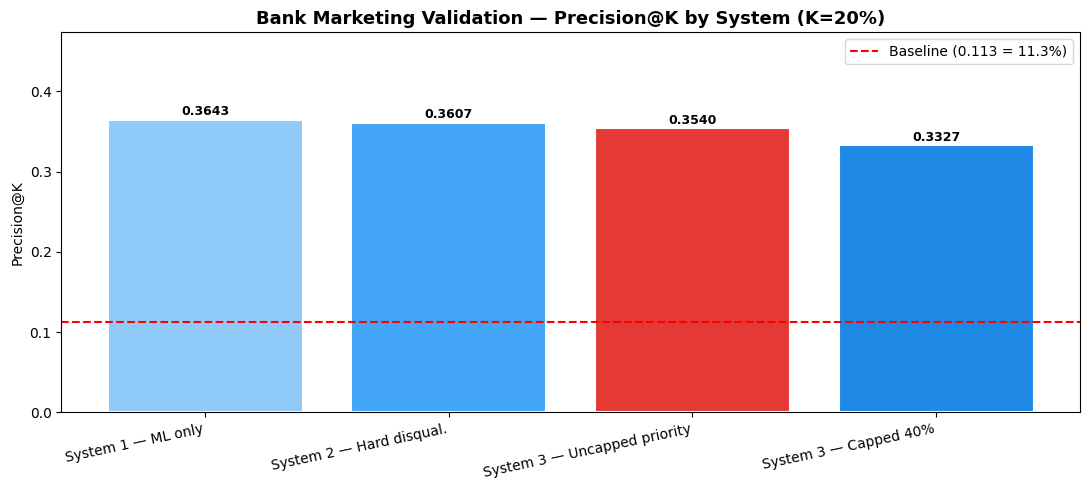

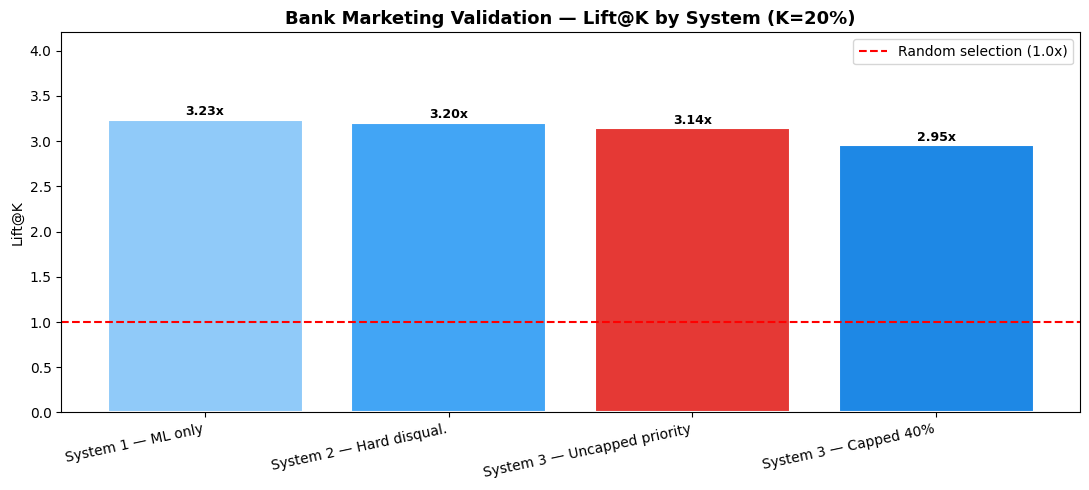

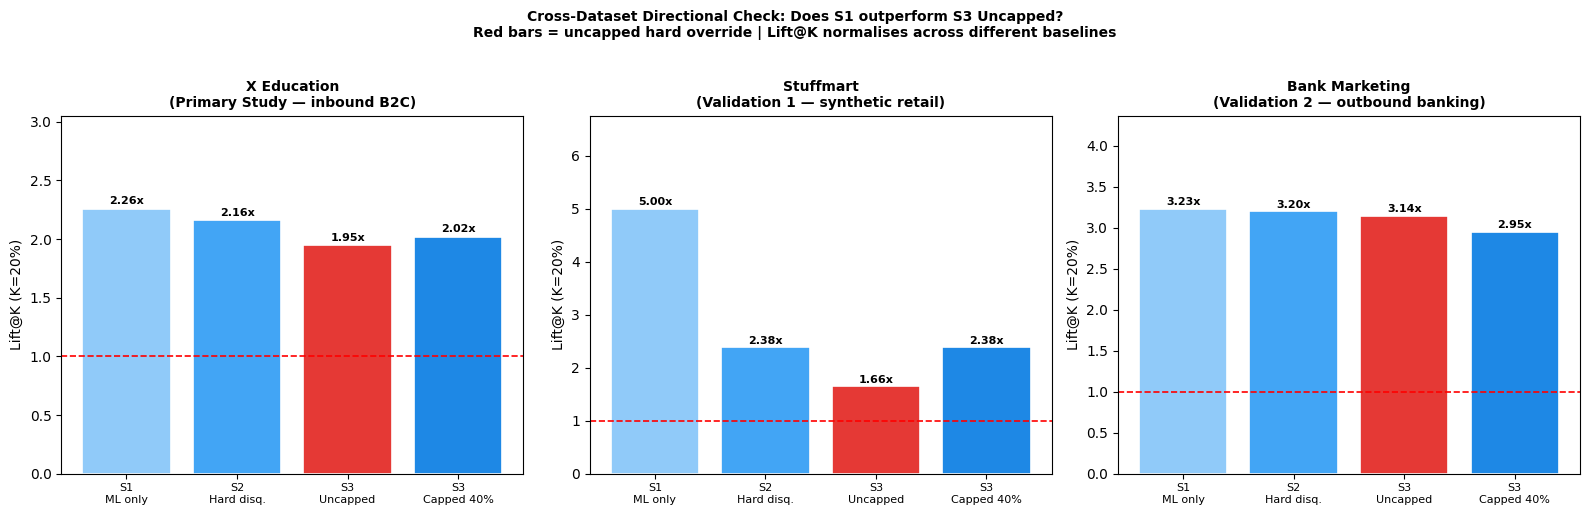

In [28]:


# =============================================================================
# CELL BM-11 — VISUALISATIONS
# =============================================================================

systems_order = [
    "System 1 — ML only",
    "System 2 — Hard disqual.",
    "System 3 — Uncapped priority",
    "System 3 — Capped 40%",
]
colors = ["#90CAF9","#42A5F5","#E53935","#1E88E5"]

# --- BM-11a. Main Precision@K ---
fig, ax = plt.subplots(figsize=(11, 5))
prec_vals = [bm_main_results[bm_main_results["system"]==s]["precision_at_k"].values[0]
             for s in systems_order]
bars = ax.bar(systems_order, prec_vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(BM_BASELINE_RATE, color="red", linestyle="--",
           label=f"Baseline ({BM_BASELINE_RATE:.3f} = {BM_BASELINE_RATE*100:.1f}%)")
for bar, val in zip(bars, prec_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Bank Marketing Validation — Precision@K by System (K=20%)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Precision@K")
ax.set_ylim(0, max(prec_vals)*1.3)
ax.legend()
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig("fig_BM_01_precision_comparison.png", dpi=150)
plt.show()

# --- BM-11b. Lift@K ---
fig, ax = plt.subplots(figsize=(11, 5))
lift_vals = [bm_main_results[bm_main_results["system"]==s]["lift_at_k"].values[0]
             for s in systems_order]
bars = ax.bar(systems_order, lift_vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(1.0, color="red", linestyle="--", label="Random selection (1.0x)")
for bar, val in zip(bars, lift_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Bank Marketing Validation — Lift@K by System (K=20%)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Lift@K")
ax.set_ylim(0, max(lift_vals)*1.3)
ax.legend()
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig("fig_BM_02_lift_comparison.png", dpi=150)
plt.show()

# --- BM-11c. Three-dataset Lift@K comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    {
        "title": "X Education\n(Primary Study — inbound B2C)",
        "labels": ["S1\nML only","S2\nHard disq.","S3\nUncapped","S3\nCapped 40%"],
        "lifts":  [2.26, 2.16, 1.95, 2.02],
        "baseline": 1.0,
    },
    {
        "title": "Stuffmart\n(Validation 1 — synthetic retail)",
        "labels": ["S1\nML only","S2\nHard disq.","S3\nUncapped","S3\nCapped 40%"],
        "lifts":  [5.00, 2.38, 1.66, 2.38],
        "baseline": 1.0,
    },
    {
        "title": "Bank Marketing\n(Validation 2 — outbound banking)",
        "labels": ["S1\nML only","S2\nHard disq.","S3\nUncapped","S3\nCapped 40%"],
        "lifts":  lift_vals,
        "baseline": 1.0,
    },
]

for ax, d in zip(axes, datasets):
    bar_colors = ["#90CAF9","#42A5F5","#E53935","#1E88E5"]
    bars = ax.bar(d["labels"], d["lifts"], color=bar_colors,
                  edgecolor="white", linewidth=1.2)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
    for bar, val in zip(bars, d["lifts"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{val:.2f}x", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(d["title"], fontsize=10, fontweight="bold")
    ax.set_ylabel("Lift@K (K=20%)")
    ax.set_ylim(0, max(d["lifts"])*1.35)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle(
    "Cross-Dataset Directional Check: Does S1 outperform S3 Uncapped?\n"
    "Red bars = uncapped hard override | Lift@K normalises across different baselines",
    fontsize=10, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_BM_03_three_dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



In [29]:


# =============================================================================
# CELL BM-12 — INTERPRETATION
# =============================================================================

s1_bm  = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["precision_at_k"].values[0]
s2_bm  = bm_main_results[bm_main_results["system"]=="System 2 — Hard disqual."]["precision_at_k"].values[0]
s3u_bm = bm_main_results[bm_main_results["system"]=="System 3 — Uncapped priority"]["precision_at_k"].values[0]
s3c_bm = bm_main_results[bm_main_results["system"]=="System 3 — Capped 40%"]["precision_at_k"].values[0]

l1_bm  = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["lift_at_k"].values[0]
l2_bm  = bm_main_results[bm_main_results["system"]=="System 2 — Hard disqual."]["lift_at_k"].values[0]
l3u_bm = bm_main_results[bm_main_results["system"]=="System 3 — Uncapped priority"]["lift_at_k"].values[0]
l3c_bm = bm_main_results[bm_main_results["system"]=="System 3 — Capped 40%"]["lift_at_k"].values[0]

p1_count = bm_results["p1_flag"].sum()
tsr_val  = p1_count / BM_K
dir_holds = s1_bm > s3u_bm

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║    CHAPTER 4.8 — BANK MARKETING EXTERNAL VALIDATION INTERPRETATION         ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET CONTEXT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Dataset       : UCI Bank Marketing (Moro et al., 2014)
  Context       : Outbound telemarketing — Portuguese banking institution
  Test set      : {len(bm_results):,} clients  |  K={BM_K:,}
  Baseline rate : {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)
  Scoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})

  Comparison with other studies (Lift@K at K=20%):
    X Education (primary, inbound B2C):    S1=2.26x  S3-uncapped=1.95x
    Stuffmart   (validation 1, synthetic): S1=5.00x  S3-uncapped=1.66x
    Bank Mktg   (validation 2, outbound):  S1={l1_bm:.2f}x  S3-uncapped={l3u_bm:.2f}x

  NOTE: Absolute Precision@K values differ across datasets due to different
  baseline rates. Lift@K is the correct cross-dataset comparison metric.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
POLICY RULE DIAGNOSTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  H1 (no prior relationship):     {bm_results['h1_flag'].sum():,} ({bm_results['h1_flag'].mean()*100:.1f}%)
  H2 (campaign >= {H2_CAMPAIGN_THRESHOLD} contacts):    {bm_results['h2_flag'].sum():,} ({bm_results['h2_flag'].mean()*100:.1f}%)
  Total disqualified:             {(bm_results['h1_flag']|bm_results['h2_flag']).sum():,} ({(bm_results['h1_flag']|bm_results['h2_flag']).mean()*100:.1f}%)
  P1 (poutcome = success):        {p1_count:,} ({bm_results['p1_flag'].mean()*100:.1f}%)
  P2 (contact = cellular):        {bm_results['p2_flag'].sum():,} ({bm_results['p2_flag'].mean()*100:.1f}%)

  TSR = {tsr_val:.2f}  {"⚠ tier saturation occurs in uncapped design" if tsr_val > 1 else "✓ TSR <= 1.0 — no saturation risk at K=20%"}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAIN RESULTS (K=20%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  System 1 — ML only            P@K={s1_bm:.4f}  Lift={l1_bm:.2f}x
  System 2 — Hard disqual.      P@K={s2_bm:.4f}  Lift={l2_bm:.2f}x
  System 3 — Uncapped priority  P@K={s3u_bm:.4f}  Lift={l3u_bm:.2f}x
  System 3 — Capped 40%         P@K={s3c_bm:.4f}  Lift={l3c_bm:.2f}x
  Baseline (random)              P@K={BM_BASELINE_RATE:.4f}  Lift=1.00x

  S1→S2 cost (Lift): {(l2_bm-l1_bm):+.2f}x
  S2→S3 uncapped cost (Lift): {(l3u_bm-l2_bm):+.2f}x
  S2→S3 capped cost (Lift):   {(l3c_bm-l2_bm):+.2f}x

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DIRECTIONAL FINDING CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Primary question: Does S1 outperform S3_uncapped?

  X Education  : S1=2.26x  S3_uncapped=1.95x  S1 > S3u: TRUE
  Stuffmart    : S1=5.00x  S3_uncapped=1.66x  S1 > S3u: TRUE
  Bank Mktg    : S1={l1_bm:.2f}x  S3_uncapped={l3u_bm:.2f}x  S1 > S3u: {"TRUE ✓" if dir_holds else "FALSE ✗"}

  {"✓ DIRECTIONAL FINDING CONSISTENT across all three datasets." if dir_holds else "✗ DIRECTIONAL FINDING NOT CONSISTENT in this dataset."}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REQUIRED CAUTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  (1) OUTBOUND vs INBOUND: This dataset represents outbound telemarketing.
      The primary study addresses inbound lead qualification. The structural
      problem (K-constrained selection) is the same; the operational
      direction is reversed. This is a genuine contextual difference.

  (2) PROXY RULES: H1, H2, P1, P2 are operationally analogous but not
      semantically equivalent to X Education rules. In particular, H1
      (no prior relationship) is a weaker proxy than an explicit opt-out.

  (3) DURATION EXCLUDED: The leakage variable 'duration' was excluded.
      Had it been included, AUC would be near-perfect (analogous to the
      Location leakage in Stuffmart). The exclusion is methodologically
      correct and consistent with UCI repository documentation.

  (4) These results are directional indicators only — no bootstrap
      confidence intervals are reported for this validation exercise.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WRITE-UP PARAGRAPH FOR CHAPTER 4.8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  "A second external validation exercise applied the constrained
  qualification framework to the UCI Bank Marketing dataset (Moro et al.,
  2014), which contains {len(df):,} records from outbound telemarketing
  campaigns of a Portuguese banking institution (baseline subscription
  rate {BM_BASELINE_RATE*100:.1f}%). Unlike the primary study (inbound lead
  qualification) and Stuffmart (synthetic retail), this dataset represents
  an outbound campaign selection context — the structural problem remains
  identical (select K contacts subject to capacity and policy constraints)
  but the operational direction is reversed. The 'duration' feature was
  excluded as a known leakage variable, consistent with the UCI repository
  documentation. {best_model_name} achieved AUC-ROC of {best_auc:.4f}.
  At K=20%, System 1 achieved {l1_bm:.2f}x lift, while System 3 without
  tier cap achieved {l3u_bm:.2f}x lift. The Tier Saturation Ratio was
  {tsr_val:.2f}, {"indicating that tier saturation occurred in the uncapped design." if tsr_val > 1 else "indicating no tier saturation risk, consistent with the low P1 coverage of the 'previous success' signal in this dataset."}
  The directional finding — S1 outperforms S3 without tier cap —
  {"was consistent across all three validation contexts (X Education, Stuffmart, Bank Marketing), providing cross-domain evidence that uncapped hard prioritisation rules impose a ranking cost relative to ML-only selection." if dir_holds else "was not replicated in this dataset, suggesting the finding may be context-specific to datasets where the ML model strongly incorporates the priority signals."}
  Results are presented as directional indicators only and should not
  be interpreted as equal-weight evidence with the primary study."
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║    CHAPTER 4.8 — BANK MARKETING EXTERNAL VALIDATION INTERPRETATION         ║
╚══════════════════════════════════════════════════════════════════════════════╝
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET CONTEXT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
  Dataset       : UCI Bank Marketing (Moro et al., 2014)
  Context       : Outbound telemarketing — Portuguese banking institution
  Test set      : 8,238 clients  |  K=1,647
  Baseline rate : 0.1126  (11.26%)
  Scoring engine: XGBoost  (AUC-ROC: 0.8054)
 
  Comparison with other studies (Lift@K at K=20%):
    X Education (primary, inbound B2C):    S1=2.26x  S3-uncapped=1.95x
    Stuffmart   (validation 1, synthetic): S1=5.00x  S3-uncapped=1.66x
    Bank Mktg   (validation 2, outbound):  S1=3.23x  S3-uncapped=3.14x
 
  NOTE: Absolute Precision@K values differ across datasets du

End